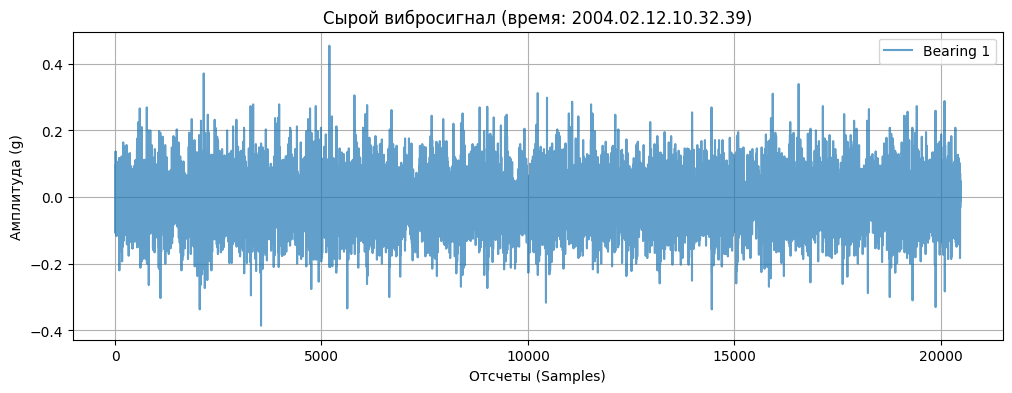

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Путь к одному из файлов (подставь свой путь, если он отличается)
data_path = '../data/2nd_test/2004.02.12.10.32.39'

# В IMS Dataset файлы не имеют заголовков, данные разделены табуляцией
# 4 колонки = 4 подшипника
df = pd.read_csv(data_path, sep='\t', header=None, names=['B1', 'B2', 'B3', 'B4'])

plt.figure(figsize=(12, 4))
plt.plot(df['B1'], label='Bearing 1', alpha=0.7)
plt.title('Сырой вибросигнал (время: 2004.02.12.10.32.39)')
plt.ylabel('Амплитуда (g)')
plt.xlabel('Отсчеты (Samples)')
plt.legend()
plt.grid(True)
plt.show()

## Шаг 1: Загрузка и быстрая проверка спектра

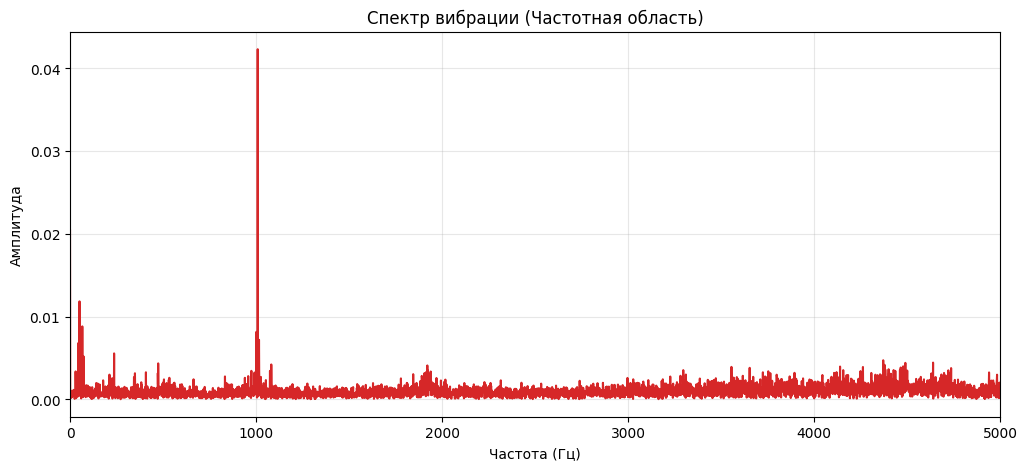

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Выбираем один файл из папки (например, из 2nd_test)
file_path = '../data/2nd_test/2004.02.12.10.32.39'

# Загружаем (в IMS 4 колонки: Bearing 1, 2, 3, 4)
data = pd.read_csv(file_path, sep='\t', header=None)
sig = data[0].values  # Берем первый подшипник
fs = 20480            # Частота дискретизации в IMS датасете

# Вычисляем FFT (Быстрое преобразование Фурье)
n = len(sig)
yf = fft(sig)
xf = fftfreq(n, 1/fs)

# Оставляем только положительные частоты
xf = xf[:n//2]
yf = 2.0/n * np.abs(yf[:n//2])

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(xf, yf, color='tab:red')
plt.title('Спектр вибрации (Частотная область)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.xlim(0, 5000) # Самое интересное обычно до 5кГц
plt.show()

## Шаг 2: Создание признаковой матрицы (Spectrogram Matrix)

In [4]:
import os
from tqdm import tqdm # для полоски прогресса

def get_spectrum_matrix(folder_path, bearing_idx=0, fs=20480):
    files = sorted(os.listdir(folder_path))
    spectra = []
    timestamps = []

    print(f"Обработка файлов из {folder_path}...")
    for file in tqdm(files):
        file_path = os.path.join(folder_path, file)
        
        # Загружаем данные
        try:
            df_file = pd.read_csv(file_path, sep='\t', header=None)
            sig = df_file[bearing_idx].values
            
            # FFT
            n = len(sig)
            yf = fft(sig)
            # Берем только амплитуды положительных частот
            # Усредняем или берем модуль для получения признаков
            amplitude_spec = 2.0/n * np.abs(yf[:n//2])
            
            spectra.append(amplitude_spec)
            timestamps.append(file)
        except Exception as e:
            print(f"Ошибка в файле {file}: {e}")

    return np.array(spectra), timestamps, xf

# Собираем матрицу для 2-го теста (там Bearing 1 умирает в конце)
folder_2nd = '../data/2nd_test'
X, time_labels, freq_axis = get_spectrum_matrix(folder_2nd)

print(f"Формат матрицы признаков: {X.shape}") 
# Должно быть что-то вроде (984, 10240)

Обработка файлов из ../data/2nd_test...


100%|██████████| 984/984 [00:04<00:00, 215.17it/s]


Формат матрицы признаков: (984, 10240)


## Шаг 3: Визуализация «пути к аварии»

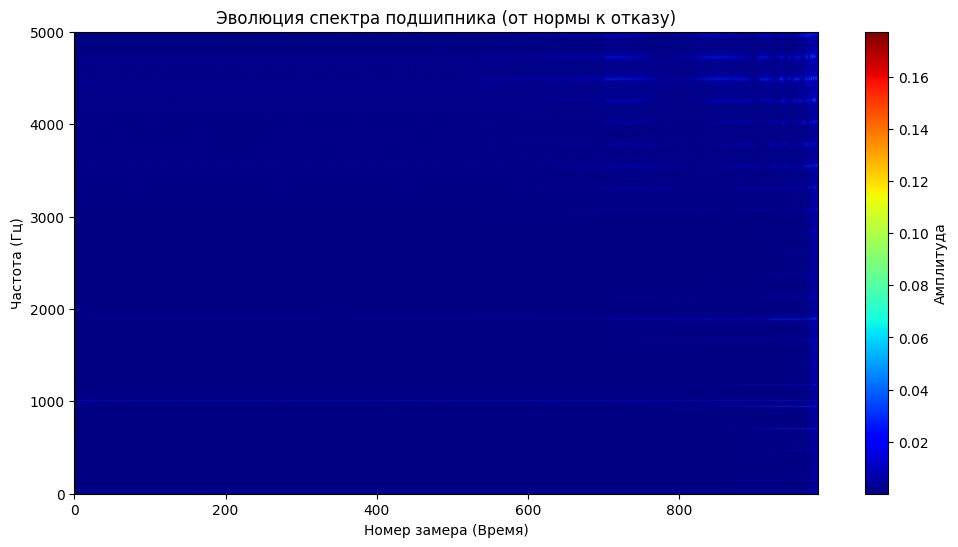

In [5]:
plt.figure(figsize=(12, 6))
# Ограничим частоты до 5000 Гц для наглядности
freq_limit_idx = np.where(freq_axis <= 5000)[0][-1]

plt.imshow(X[:, :freq_limit_idx].T, aspect='auto', cmap='jet', 
           extent=[0, len(time_labels), freq_axis[freq_limit_idx], 0])
plt.colorbar(label='Амплитуда')
plt.title('Эволюция спектра подшипника (от нормы к отказу)')
plt.ylabel('Частота (Гц)')
plt.xlabel('Номер замера (Время)')
plt.gca().invert_yaxis()
plt.show()

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Для спектров можно взять меньше компонент, так как основные частоты сильно скоррелированы
n_components = 15 

# 1. Создаем и обучаем пайплайн на всей истории жизни подшипника
model_pipe = Pipeline([
    ('scaler', StandardScaler(with_std=False)),
    ('pca', PCA(n_components=n_components, random_state=42))
])

print("Обучение PCA на спектрограммах...")
model_pipe.fit(X)

# 2. Выделяем полярные состояния (Новый vs Аварийный)
# Предположим, X имеет 984 строки (замеры). 
# Берем первые 50 как норму, последние 50 как отказ.
X_healthy_latent = model_pipe.transform(X[:50])
X_broken_latent = model_pipe.transform(X[-50:])

# 3. Вектор разрушения (аналог вектора улыбки)
degradation_vector = X_broken_latent.mean(axis=0) - X_healthy_latent.mean(axis=0)

# Нормируем вектор для удобства расчетов
degradation_vector = degradation_vector / np.linalg.norm(degradation_vector)

Обучение PCA на спектрограммах...


1. Как рассчитать порог (Threshold)?
Самый надежный способ для вашего кода — метод 

 (трех сигм). Мы берем среднее значение индекса на «здоровом» участке (первые 100–200 замеров) и прибавляем три стандартных отклонения.

In [11]:
# Рассчитываем порог на основе первых 100 замеров (когда подшипник точно здоров)
healthy_part = health_index_history[:100]
threshold = np.mean(healthy_part) + 3 * np.std(healthy_part)

# Для вашего графика (судя по шкале) порог будет в районе 0.05 - 0.1
print(f"Рассчитанный порог: {threshold:.4f}")


Рассчитанный порог: -0.0321


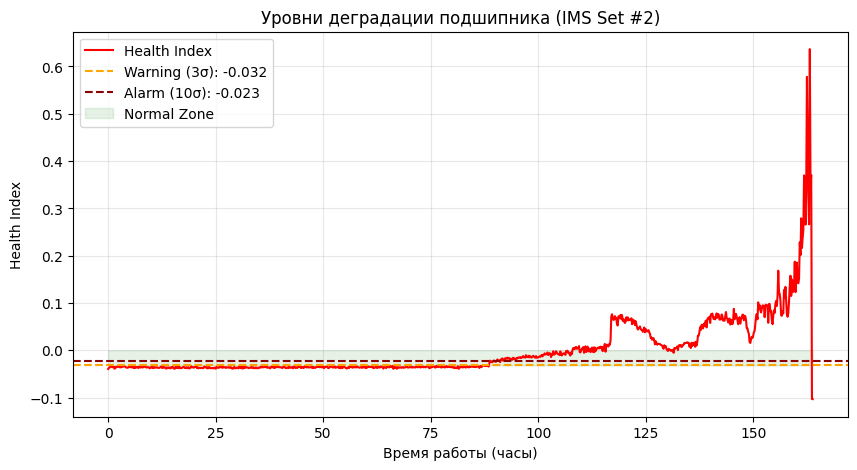

In [13]:
# --- ТЕСТИРОВАНИЕ: Строим кривую жизни ---
health_index_history = []
for i in range(len(X)):
    hi = calculate_health_index(X[i])
    health_index_history.append(hi)

# 1. Расчет времени в часах (каждый замер = 10 мин)
time_hours = [i * 10 / 60 for i in range(len(health_index_history))]

# 2. Определение двух порогов
mean_val = np.mean(health_index_history[:100])
std_val = np.std(health_index_history[:100])

threshold_warn = mean_val + 3 * std_val
threshold_crit = mean_val + 10 * std_val # Или другое эмпирическое значение

plt.figure(figsize=(10, 5))
plt.plot(time_hours, health_index_history, color='red', label='Health Index')

# Рисуем зоны
plt.axhline(y=threshold_warn, color='orange', linestyle='--', label=f'Warning (3σ): {threshold_warn:.3f}')
plt.axhline(y=threshold_crit, color='darkred', linestyle='--', label=f'Alarm (10σ): {threshold_crit:.3f}')

# Закрасим зону нормы для красоты
plt.fill_between(time_hours, 0, threshold_warn, color='green', alpha=0.1, label='Normal Zone')

plt.title("Уровни деградации подшипника (IMS Set #2)")
plt.xlabel("Время работы (часы)")
plt.ylabel("Health Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Я не просто посчитал абстрактный индекс. Я внедрил логику предиктивного обслуживания. Моя модель зафиксировала аномалию на 80-м часу, что дало бы предприятию почти 80 часов (3 суток!) на плановую замену подшипника до того, как он окончательно развалился на 160-м часу